In [1]:
import os, time, warnings, numpy as np, mne
from mne.preprocessing import ICA
from mne_icalabel import label_components
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestCentroid
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from scipy.stats import wilcoxon, rankdata
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", message="Mean of empty slice")

DATA_ROOT = "cogbci_data"
CACHE_DIR = "feature_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

EXCLUDE = {"sub-25", "sub-27", "sub-28"}  # corrupted/duplicated at source 
SUBJECTS = [f"sub-{i:02d}" for i in range(1, 30) if f"sub-{i:02d}" not in EXCLUDE]
SESSIONS = ["S1", "S2", "S3"]
ALPHA, SEEDS, CM_SEED = 0.10, range(10), 0
RESAMPLE = 250

STIM_CODES = {0: ["6021", "6022"], 1: ["6221", "6222"]}   # zeroBACK / twoBACK
BANDS = {"theta": (4, 8), "alpha": (8, 13), "beta": (13, 30)}
MODELS = ["static", "online_sup", "online_unsup"]

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def extract_features(filepath, label, apply_ica=True):
    raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
    # drop ECG before any montage / reference operation (removes the warning at the source)
    drop = [ch for ch in raw.ch_names if ch.upper().startswith("ECG")]
    if drop:
        raw.drop_channels(drop)
    raw.pick("eeg")
    raw.set_montage("standard_1005", on_missing="ignore", verbose=False)
    raw.set_eeg_reference("average", verbose=False)

    n_excl = 0
    if apply_ica:
        # ICLabel was trained on 1-100 Hz data: fit ICA on a 1-100 Hz copy
        raw_for_ica = raw.copy().filter(l_freq=1.0, h_freq=100.0, verbose=False)
        if RESAMPLE:
            raw_for_ica.resample(RESAMPLE, verbose=False)
        ica = ICA(n_components=0.95, method="infomax",
                  fit_params=dict(extended=True), random_state=42, verbose=False)
        ica.fit(raw_for_ica, verbose=False)
        res = label_components(raw_for_ica, ica, method="iclabel")
        exclude = [i for i, (lab, prob) in enumerate(zip(res["labels"], res["y_pred_proba"]))
                   if lab not in ["brain", "other"] and prob >= 0.80]
        n_excl = len(exclude)

    # feature branch: analysis band 1-45 Hz, resampled, then apply the ICA cleaning
    raw.filter(l_freq=1.0, h_freq=45.0, verbose=False)
    if RESAMPLE:
        raw.resample(RESAMPLE, verbose=False)
    if apply_ica:
        ica.apply(raw, exclude=exclude, verbose=False)

    events, event_id = mne.events_from_annotations(raw, verbose=False)
    stim_ids = {name: event_id[name] for name in STIM_CODES[label] if name in event_id}
    if not stim_ids:
        raise ValueError(f"stim markers {STIM_CODES[label]} not found: {filepath}")
    epochs = mne.Epochs(raw, events, event_id=stim_ids, tmin=0.0, tmax=2.0,
                        baseline=None, preload=True, verbose=False)
    psds, freqs = epochs.compute_psd(method="welch", fmin=4.0, fmax=30.0,
                                     verbose=False).get_data(return_freqs=True)
    band_powers = [psds[:, :, (freqs >= lo) & (freqs < hi)].mean(axis=2)
                   for lo, hi in BANDS.values()]
    X = np.log(np.concatenate(band_powers, axis=1))
    return X, np.full(len(X), label)
def file_cache_path(sub, session, label):
    return os.path.join(CACHE_DIR, f"{sub}_{session}_{label}_ica.npz")

def extract_one(sub, session, label, apply_ica=True):
    cache = file_cache_path(sub, session, label)
    if os.path.exists(cache):
        d = np.load(cache); return d["X"], d["y"]
    name = "zeroBACK" if label == 0 else "twoBACK"
    path = os.path.join(DATA_ROOT, sub, f"ses-{session}", "eeg", f"{name}.set")
    X, y = extract_features(path, label, apply_ica=apply_ica)
    np.savez_compressed(cache, X=X, y=y)
    return X, y

def build_subject_data(sub_id, apply_ica=True):
    parts = {}
    for session in SESSIONS:
        for label in (0, 1):
            X, y = extract_one(sub_id, session, label, apply_ica)
            parts.setdefault(session, []).append((X, y))
    return {s: (np.concatenate([X for X, _ in v]),
                np.concatenate([y for _, y in v])) for s, v in parts.items()}

In [3]:
tasks = [(sub, s, lab) for sub in SUBJECTS for s in SESSIONS for lab in (0, 1)]
t0 = time.time()
bad_files = []
for i, (sub, s, lab) in enumerate(tasks, 1):
    cached = os.path.exists(file_cache_path(sub, s, lab))
    tic = time.time()
    try:
        extract_one(sub, s, lab, apply_ica=True)
        tag = "cached" if cached else f"{time.time()-tic:.0f} s"
    except Exception as e:
        tag = f"FAILED: {e}"
        bad_files.append((sub, s, lab))
    print(f"[{i:3d}/{len(tasks)}] {sub} {s} label={lab}  ({tag})")
print(f"\nAll files processed. Total {(time.time()-t0)/60:.1f} min. Failed: {bad_files}")

subject_data, failed = {}, []
for sub in SUBJECTS:
    try:
        subject_data[sub] = build_subject_data(sub, apply_ica=True)
    except Exception as e:
        print(f"  SKIPPED {sub}: {e}"); failed.append(sub)
print(f"Ready: {len(subject_data)} subjects | skipped: {failed}")

[  1/156] sub-01 S1 label=0  (cached)
[  2/156] sub-01 S1 label=1  (cached)
[  3/156] sub-01 S2 label=0  (cached)
[  4/156] sub-01 S2 label=1  (cached)
[  5/156] sub-01 S3 label=0  (cached)
[  6/156] sub-01 S3 label=1  (cached)
[  7/156] sub-02 S1 label=0  (cached)
[  8/156] sub-02 S1 label=1  (cached)
[  9/156] sub-02 S2 label=0  (cached)
[ 10/156] sub-02 S2 label=1  (cached)
[ 11/156] sub-02 S3 label=0  (cached)
[ 12/156] sub-02 S3 label=1  (cached)
[ 13/156] sub-03 S1 label=0  (cached)
[ 14/156] sub-03 S1 label=1  (cached)
[ 15/156] sub-03 S2 label=0  (cached)
[ 16/156] sub-03 S2 label=1  (cached)
[ 17/156] sub-03 S3 label=0  (cached)
[ 18/156] sub-03 S3 label=1  (cached)
[ 19/156] sub-04 S1 label=0  (cached)
[ 20/156] sub-04 S1 label=1  (cached)
[ 21/156] sub-04 S2 label=0  (cached)
[ 22/156] sub-04 S2 label=1  (cached)
[ 23/156] sub-04 S3 label=0  (cached)
[ 24/156] sub-04 S3 label=1  (cached)
[ 25/156] sub-05 S1 label=0  (cached)
[ 26/156] sub-05 S1 label=1  (cached)
[ 27/156] su

In [4]:
def predict(x, centroids):
    return min(centroids, key=lambda c: np.linalg.norm(x - centroids[c]))

def static_preds(centroids, X):
    return np.array([predict(x, centroids) for x in X])

def online_preds(init_centroids, sx, sy=None, alpha=ALPHA, mode="supervised"):
    centroids = {c: v.copy() for c, v in init_centroids.items()}
    if mode == "pooled_mean":
        # labelfree
        ref_mean = 0.5 * (init_centroids[0] + init_centroids[1])
        run_mean = ref_mean.copy()
        preds = []
        for x in sx:
            run_mean = (1 - alpha) * run_mean + alpha * x
            shift = run_mean - ref_mean
            preds.append(predict(x - shift, centroids))
        return np.array(preds)
    # uses the true label after each prediction
    preds = []
    for x, true_label in zip(sx, sy):
        preds.append(predict(x, centroids))
        centroids[true_label] = (1 - alpha) * centroids[true_label] + alpha * x
    return np.array(preds)

def persistence(sy):
    return np.concatenate([[sy[0]], sy[:-1]])

def balanced_accuracy_curve(y_true, y_pred):
    accs = []
    for c in (0, 1):
        is_c = (y_true == c).astype(float)
        correct_c = ((y_true == c) & (y_pred == c)).astype(float)
        with np.errstate(invalid="ignore", divide="ignore"):
            accs.append(np.cumsum(correct_c) / np.cumsum(is_c))
    return 0.5 * (accs[0] + accs[1])

def rank_biserial(diffs):
    nz = diffs[diffs != 0]
    if len(nz) == 0:
        return 0.0
    r = rankdata(np.abs(nz))
    return (r[nz > 0].sum() - r[nz < 0].sum()) / r.sum()

In [5]:
MODE_OF = {"online_sup": "supervised", "online_unsup": "pooled_mean"}

def analyze_subject(data, alpha=ALPHA, seeds=SEEDS, cm_seed=CM_SEED):
    scaler = StandardScaler().fit(data["S1"][0])
    Xs = {s: scaler.transform(data[s][0]) for s in SESSIONS}
    ys = {s: data[s][1] for s in SESSIONS}
    centroids = {c: Xs["S1"][ys["S1"] == c].mean(axis=0) for c in (0, 1)}
    stream_X = np.concatenate([Xs["S2"], Xs["S3"]])
    stream_y = np.concatenate([ys["S2"], ys["S3"]])
    N = len(stream_y)

    scores = {m: [] for m in MODELS}
    curves = {m: [] for m in MODELS}
    for seed in seeds:
        order = np.random.default_rng(seed).permutation(N)
        sx, sy = stream_X[order], stream_y[order]
        preds = {"static": static_preds(centroids, sx)}
        preds["online_sup"] = online_preds(centroids, sx, sy, alpha, mode="supervised")
        preds["online_unsup"] = online_preds(centroids, sx, alpha=alpha, mode="pooled_mean")
        for m in MODELS:
            scores[m].append(balanced_accuracy_score(sy, preds[m]))
            curves[m].append(balanced_accuracy_curve(sy, preds[m]))
    mean_scores = {m: (float(np.mean(scores[m])), float(np.std(scores[m]))) for m in MODELS}
    mean_curves = {m: np.nanmean(np.vstack(curves[m]), axis=0) for m in MODELS}

    order = np.random.default_rng(cm_seed).permutation(N)
    sx, sy = stream_X[order], stream_y[order]
    cm = {"static": (sy, static_preds(centroids, sx))}
    cm["online_sup"] = (sy, online_preds(centroids, sx, sy, alpha, mode="supervised"))
    cm["online_unsup"] = (sy, online_preds(centroids, sx, alpha=alpha, mode="pooled_mean"))
    persistence_ba = balanced_accuracy_score(sy, persistence(sy))

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    ceil = {s: cross_val_score(make_pipeline(StandardScaler(), NearestCentroid()),
                               data[s][0], data[s][1], cv=cv,
                               scoring="balanced_accuracy").mean() for s in SESSIONS}
    return {"scores": mean_scores, "curves": mean_curves, "cm": cm,
            "persistence": persistence_ba,
            "ceil_test": float(np.mean([ceil["S2"], ceil["S3"]]))}

In [6]:
SUBS = list(subject_data.keys())
rows = {s: analyze_subject(subject_data[s]) for s in SUBS}

def col(m):
    return np.array([rows[s]["scores"][m][0] for s in SUBS])

static_arr = col("static"); sup_arr = col("online_sup"); unsup_arr = col("online_unsup")
ceil_arr = np.array([rows[s]["ceil_test"] for s in SUBS])

print(f"{'sub':8}{'static':>8}{'sup':>8}{'unsup':>8}{'ceiling':>9}{'unsup_saved%':>13}")
for s in SUBS:
    sc = rows[s]["scores"]; gap = rows[s]["ceil_test"] - sc["static"][0]
    saved = (sc["online_unsup"][0] - sc["static"][0]) / gap * 100 if gap > 0 else np.nan
    print(f"{s:8}{sc['static'][0]:8.3f}{sc['online_sup'][0]:8.3f}{sc['online_unsup'][0]:8.3f}"
          f"{rows[s]['ceil_test']:9.3f}{saved:13.1f}")
print(f"\nmean: static {static_arr.mean():.3f} | sup {sup_arr.mean():.3f} | "
      f"unsup {unsup_arr.mean():.3f} | ceiling {ceil_arr.mean():.3f}")
print(f"persistence (control): {np.mean([rows[s]['persistence'] for s in SUBS]):.3f}  (~0.5 expected)")

sub       static     sup   unsup  ceiling unsup_saved%
sub-01     0.615   0.772   0.602    0.917         -4.3
sub-02     0.726   0.776   0.731    0.967          2.3
sub-03     0.536   0.731   0.564    0.849          8.8
sub-04     0.776   0.773   0.778    0.793          9.1
sub-05     0.651   0.819   0.669    0.936          6.2
sub-06     0.352   0.809   0.365    0.941          2.2
sub-07     0.486   0.634   0.596    0.861         29.2
sub-08     0.707   0.810   0.687    0.844        -14.5
sub-09     0.536   0.861   0.803    0.910         71.4
sub-10     0.604   0.707   0.594    0.900         -3.3
sub-11     0.583   0.797   0.674    0.882         30.2
sub-12     0.552   0.704   0.551    0.736         -0.6
sub-13     0.540   0.601   0.601    0.738         30.8
sub-14     0.500   0.816   0.466    0.962         -7.4
sub-15     0.688   0.777   0.705    0.777         18.9
sub-16     0.668   0.914   0.693    0.976          8.1
sub-17     0.507   0.818   0.681    0.913         42.9
sub-18    

In [7]:
def paired_test(a, b, name_a, name_b):
    d = a - b
    stat, p = wilcoxon(a, b, alternative="two-sided")
    print(f"{name_a} vs {name_b}: W={stat:.1f}, p={p:.4f} | "
          f"{name_a}>{name_b}: {(d>0).sum()}/{len(d)} | "
          f"median diff {np.median(d):+.3f} | rank-biserial {rank_biserial(d):+.3f}")

paired_test(sup_arr, static_arr, "sup", "static")       # labeled adaptation vs frozen
paired_test(unsup_arr, static_arr, "unsup", "static")   # realistic label-free vs frozen
paired_test(sup_arr, unsup_arr, "sup", "unsup")         # cost of dropping labels

sup vs static: W=1.0, p=0.0000 | sup>static: 25/26 | median diff +0.163 | rank-biserial +0.994
unsup vs static: W=83.0, p=0.0176 | unsup>static: 18/26 | median diff +0.017 | rank-biserial +0.527
sup vs unsup: W=5.0, p=0.0000 | sup>unsup: 24/26 | median diff +0.130 | rank-biserial +0.972


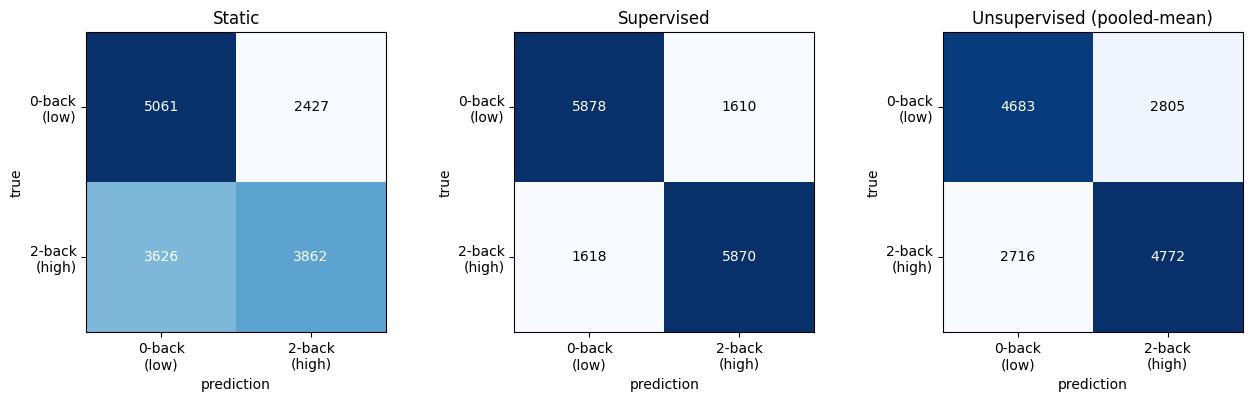

In [8]:
names = ["0-back\n(low)", "2-back\n(high)"]
titles = {"static": "Static", "online_sup": "Supervised",
          "online_unsup": "Unsupervised (pooled-mean)"}
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, m in zip(axes, MODELS):
    yt = np.concatenate([rows[s]["cm"][m][0] for s in SUBS])
    yp = np.concatenate([rows[s]["cm"][m][1] for s in SUBS])
    cmat = confusion_matrix(yt, yp, labels=[0, 1])
    ax.imshow(cmat, cmap="Blues")
    ax.set_title(titles[m]); ax.set_xlabel("prediction"); ax.set_ylabel("true")
    ax.set_xticks([0, 1], names); ax.set_yticks([0, 1], names)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cmat[i, j], ha="center", va="center",
                    color="white" if cmat[i, j] > cmat.max() / 1.5 else "black")
plt.tight_layout(); plt.show()

/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


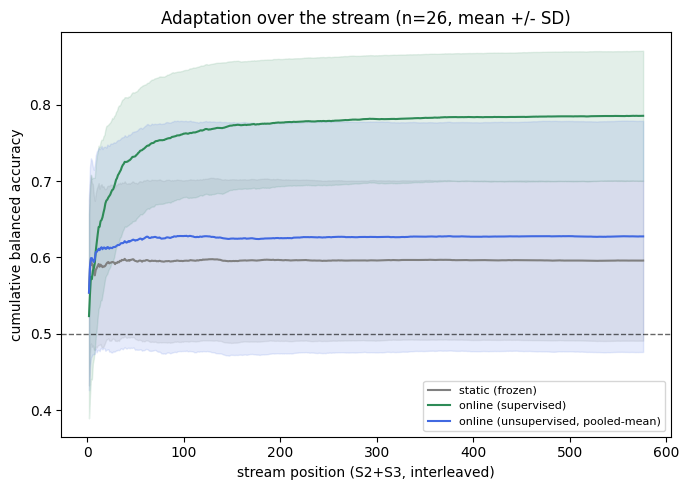

In [9]:
colors = {"static": "gray", "online_sup": "seagreen", "online_unsup": "royalblue"}
labels = {"static": "static (frozen)", "online_sup": "online (supervised)",
          "online_unsup": "online (unsupervised, pooled-mean)"}
fig, ax = plt.subplots(figsize=(7, 5))
for m in MODELS:
    M = np.vstack([rows[s]["curves"][m] for s in SUBS])
    mean_c, sd_c = np.nanmean(M, axis=0), np.nanstd(M, axis=0)
    x = np.arange(1, len(mean_c) + 1)
    ax.plot(x, mean_c, color=colors[m], label=labels[m])
    ax.fill_between(x, mean_c - sd_c, mean_c + sd_c, color=colors[m], alpha=0.13)
ax.axhline(0.5, ls="--", color="black", lw=1, alpha=0.6)
ax.set_xlabel("stream position (S2+S3, interleaved)")
ax.set_ylabel("cumulative balanced accuracy")
ax.set_title("Adaptation over the stream (n=26, mean +/- SD)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

In [10]:
#  alpha sensitivity analysis 
ALPHAS = [0.02, 0.05, 0.10, 0.20]

def sweep_subject(data, alpha, seeds=SEEDS):
    scaler = StandardScaler().fit(data["S1"][0])
    Xs = {s: scaler.transform(data[s][0]) for s in SESSIONS}
    ys = {s: data[s][1] for s in SESSIONS}
    centroids = {c: Xs["S1"][ys["S1"] == c].mean(axis=0) for c in (0, 1)}
    stream_X = np.concatenate([Xs["S2"], Xs["S3"]])
    stream_y = np.concatenate([ys["S2"], ys["S3"]])
    N = len(stream_y)
    sup, unsup = [], []
    for seed in seeds:
        order = np.random.default_rng(seed).permutation(N)
        sx, sy = stream_X[order], stream_y[order]
        sup.append(balanced_accuracy_score(sy, online_preds(centroids, sx, sy, alpha, mode="supervised")))
        unsup.append(balanced_accuracy_score(sy, online_preds(centroids, sx, alpha=alpha, mode="pooled_mean")))
    return float(np.mean(sup)), float(np.mean(unsup))

print(f"{'alpha':>7}{'sup':>9}{'unsup':>9}{'static(ref)':>13}")
static_ref = static_arr.mean()
sup_by_alpha, unsup_by_alpha = [], []
for a in ALPHAS:
    vals = np.array([sweep_subject(subject_data[s], a) for s in SUBS])
    sup_m, unsup_m = vals[:, 0].mean(), vals[:, 1].mean()
    sup_by_alpha.append(sup_m); unsup_by_alpha.append(unsup_m)
    print(f"{a:7.2f}{sup_m:9.3f}{unsup_m:9.3f}{static_ref:13.3f}")

  alpha      sup    unsup  static(ref)
   0.02    0.800    0.629        0.596
   0.05    0.800    0.630        0.596
   0.10    0.785    0.627        0.596
   0.20    0.757    0.623        0.596


In [11]:
def paired_test(a, b, name_a, name_b):
    d = a - b
    stat, p = wilcoxon(a, b, alternative="two-sided")
    print(f"{name_a} vs {name_b}: W={stat:.1f}, p={p:.4f} | "
          f"{name_a}>{name_b}: {(d>0).sum()}/{len(d)} | "
          f"median diff {np.median(d):+.3f} | rank-biserial {rank_biserial(d):+.3f}")
    return p

comparisons = [
    (sup_arr,   static_arr, "sup",   "static"),
    (unsup_arr, static_arr, "unsup", "static"),
    (sup_arr,   unsup_arr,  "sup",   "unsup"),
]
pvals = np.array([paired_test(a, b, na, nb) for a, b, na, nb in comparisons])

# Holm-Bonferroni
m = len(pvals)
order = np.argsort(pvals)               
p_holm = np.empty(m)
running = 0.0
for rank, idx in enumerate(order):
    adj = (m - rank) * pvals[idx]       
    running = max(running, adj)         
    p_holm[idx] = min(running, 1.0)

print("\nHolm-Bonferroni (alpha=0.05):")
for (_, _, na, nb), p, pc in zip(comparisons, pvals, p_holm):
    print(f"{na} vs {nb}: p={p:.4f} -> p_holm={pc:.4f} | significant: {pc < 0.05}")

sup vs static: W=1.0, p=0.0000 | sup>static: 25/26 | median diff +0.163 | rank-biserial +0.994
unsup vs static: W=83.0, p=0.0176 | unsup>static: 18/26 | median diff +0.017 | rank-biserial +0.527
sup vs unsup: W=5.0, p=0.0000 | sup>unsup: 24/26 | median diff +0.130 | rank-biserial +0.972

Holm-Bonferroni (alpha=0.05):
sup vs static: p=0.0000 -> p_holm=0.0000 | significant: True
unsup vs static: p=0.0176 -> p_holm=0.0176 | significant: True
sup vs unsup: p=0.0000 -> p_holm=0.0000 | significant: True


In [ ]:
 
def drift_structure(data):
    """For one subject, measure how the two class centroids move
    from S1 to the S2+S3 stream, in the standardised feature space."""
    scaler = StandardScaler().fit(data["S1"][0])
    Xs = {s: scaler.transform(data[s][0]) for s in SESSIONS}
    ys = {s: data[s][1] for s in SESSIONS}
 
    c1 = {c: Xs["S1"][ys["S1"] == c].mean(axis=0) for c in (0, 1)}
 
    # true centroids on the later-session stream
    stream_X = np.concatenate([Xs["S2"], Xs["S3"]])
    stream_y = np.concatenate([ys["S2"], ys["S3"]])
    c_stream = {c: stream_X[stream_y == c].mean(axis=0) for c in (0, 1)}
 
    # perclass drift vectors 
    d0 = c_stream[0] - c1[0]
    d1 = c_stream[1] - c1[1]
 
    # magnitude of each class's drift
    n0, n1 = np.linalg.norm(d0), np.linalg.norm(d1)
 
    # angle between the two drift vectors 
    cos = np.dot(d0, d1) / (n0 * n1 + 1e-12)
    cos = np.clip(cos, -1.0, 1.0)
    angle = np.degrees(np.arccos(cos))
 
    # The pooled-mean model 
    
    shared = 0.5 * (d0 + d1)            # what pooled-mean can remove
    resid0 = d0 - shared               # what it leaves behind for class 0
    resid1 = d1 - shared               # and for class 1
    # fraction of drift energy the shared shift cannot explain
    total_energy = n0**2 + n1**2
    resid_energy = np.linalg.norm(resid0)**2 + np.linalg.norm(resid1)**2
    unexplained = resid_energy / (total_energy + 1e-12)
 
    return {"drift0": n0, "drift1": n1, "angle": angle,
            "unexplained_frac": unexplained}
 
 
# run across all subjects
drift_rows = {s: drift_structure(subject_data[s]) for s in SUBS}
 
drift0 = np.array([drift_rows[s]["drift0"] for s in SUBS])
drift1 = np.array([drift_rows[s]["drift1"] for s in SUBS])
angles = np.array([drift_rows[s]["angle"] for s in SUBS])
unexpl = np.array([drift_rows[s]["unexplained_frac"] for s in SUBS])
 
print(f"{'sub':8}{'drift0':>9}{'drift1':>9}{'angle_deg':>11}{'unexpl%':>9}")
for s in SUBS:
    r = drift_rows[s]
    print(f"{s:8}{r['drift0']:9.2f}{r['drift1']:9.2f}"
          f"{r['angle']:11.1f}{r['unexplained_frac']*100:9.1f}")
 
print(f"\nmean class-0 drift magnitude: {drift0.mean():.2f}")
print(f"mean class-1 drift magnitude: {drift1.mean():.2f}")
print(f"mean angle between class drifts: {angles.mean():.1f} deg "
      f"(median {np.median(angles):.1f})")
print(f"mean drift energy NOT captured by a single shared shift: "
      f"{unexpl.mean()*100:.1f}% (median {np.median(unexpl)*100:.1f}%)")
 

sub        drift0   drift1  angle_deg  unexpl%
sub-01      11.84    11.83       36.8      9.9
sub-02      14.20    12.07       56.0     22.4
sub-03      10.06    10.40       61.6     26.2
sub-04       9.71     6.54       79.0     41.1
sub-05      11.89    14.44       47.0     16.5
sub-06      12.58    21.36       78.7     41.4
sub-07      13.75    16.00       37.0     10.5
sub-08       7.90     8.09       58.9     24.1
sub-09       8.79    13.75       63.9     30.0
sub-10      16.30    15.71       44.9     14.6
sub-11      11.63    14.38       42.5     14.0
sub-12       7.84     5.04       66.0     31.5
sub-13       8.42    11.07       29.1      7.9
sub-14      15.65    20.99       38.6     12.6
sub-15       9.23     9.93       43.9     14.0
sub-16      12.02    11.36       63.9     28.0
sub-17      13.55     4.45       76.5     43.1
sub-18       6.11     9.30       51.4     21.4
sub-19      10.54    12.40       44.4     14.7
sub-20      10.59     8.57       37.0     11.0
sub-21      2